<a href="https://colab.research.google.com/github/SantiaGaGo/Financiero---UniAndes-TodosALaU/blob/main/Ejercicio_Ethereum1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 62 kB 1.2 MB/s 
  Attempting uninstall: requests
    Found existing installation: requests 2.23.0
    Uninstalling requests-2.23.0:
      Successfully uninstalled requests-2.23.0


In [ ]:
#API datos
import yfinance as yfin

#Manejo de tablas de datos
import pandas as pd
import numpy as np

#Manejo de archivos
from google.colab import files

#Graficos
import matplotlib.pyplot as plt

In [ ]:
ticker='ETH-USD'
df= yfin.download(ticker, start= '2019-09-01', end= '2021-09-01')
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-09-01,172.458405,173.696854,169.531281,171.629425,171.629425,5554799576
2019-09-02,171.697601,180.145218,170.451691,178.347351,178.347351,6503447137
2019-09-03,178.357758,182.347992,175.970169,179.499329,179.499329,6962728938
2019-09-04,179.491989,180.136597,175.325363,175.992889,175.992889,5938120494
2019-09-05,175.966278,176.163910,171.746826,174.217133,174.217133,5589476516
...,...,...,...,...,...,...
2021-08-27,3096.406006,3281.840576,3064.485107,3270.600830,3270.600830,18489602004
2021-08-28,3275.104492,3284.845947,3217.403564,3244.403320,3244.403320,13709633698
2021-08-29,3246.770996,3283.235596,3158.840332,3227.002686,3227.002686,13296586731


In [ ]:
#Estadisticas descriptivas
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,731.000000,731.000000,731.000000,731.000000,731.000000,7.310000e+02
mean,912.624801,949.189126,873.568231,917.074084,917.074084,1.877284e+10
std,1000.540016,1044.749523,952.357791,1004.444344,1004.444344,1.197694e+10
min,110.406784,116.021622,95.184303,110.605873,110.605873,5.109033e+09
25%,188.170471,191.481842,184.261520,188.429153,188.429153,1.003360e+10
50%,368.727539,380.021515,357.569763,369.136902,369.136902,1.512372e+10
75%,1745.320190,1813.965942,1674.309570,1757.325928,1757.325928,2.374619e+10
max,4174.635742,4362.350586,3785.848633,4168.701172,4168.701172,8.448291e+10


In [ ]:
#retornos aritmeticos
df['Adj Close t-1']= df['Adj Close'].shift(1)
df['Returns']=(df['Adj Close']-df['Adj Close t-1'])/df['Adj Close t-1']

df
df.describe()

,Open,High,Low,Close,Adj Close,Volume,Adj Close t-1,Returns
count,731.000000,731.000000,731.000000,731.000000,731.000000,7.310000e+02,730.000000,730.000000
mean,912.624801,949.189126,873.568231,917.074084,917.074084,1.877284e+10,913.626606,0.005502
std,1000.540016,1044.749523,952.357791,1004.444344,1004.444344,1.197694e+10,1000.795921,0.051814
min,110.406784,116.021622,95.184303,110.605873,110.605873,5.109033e+09,110.605873,-0.423472
25%,188.170471,191.481842,184.261520,188.429153,188.429153,1.003360e+10,188.343948,-0.018351
50%,368.727539,380.021515,357.569763,369.136902,369.136902,1.512372e+10,368.996414,0.004581
75%,1745.320190,1813.965942,1674.309570,1757.325928,1757.325928,2.374619e+10,1746.023468,0.031066
max,4174.635742,4362.350586,3785.848633,4168.701172,4168.701172,8.448291e+10,4168.701172,0.259475


In [ ]:
#retornos logaritmicos
df['Log Returns']= np.log(df['Adj Close'])- np.log(df['Adj Close t-1'])
df
df.describe()

,Open,High,Low,Close,Adj Close,Volume,Adj Close t-1,Returns,Log Returns
count,731.000000,731.000000,731.000000,731.000000,731.000000,7.310000e+02,730.000000,730.000000,730.000000
mean,912.624801,949.189126,873.568231,917.074084,917.074084,1.877284e+10,913.626606,0.005502,0.004104
std,1000.540016,1044.749523,952.357791,1004.444344,1004.444344,1.197694e+10,1000.795921,0.051814,0.053367
min,110.406784,116.021622,95.184303,110.605873,110.605873,5.109033e+09,110.605873,-0.423472,-0.550732
25%,188.170471,191.481842,184.261520,188.429153,188.429153,1.003360e+10,188.343948,-0.018351,-0.018521
50%,368.727539,380.021515,357.569763,369.136902,369.136902,1.512372e+10,368.996414,0.004581,0.004571
75%,1745.320190,1813.965942,1674.309570,1757.325928,1757.325928,2.374619e+10,1746.023468,0.031066,0.030593
max,4174.635742,4362.350586,3785.848633,4168.701172,4168.701172,8.448291e+10,4168.701172,0.259475,0.230695


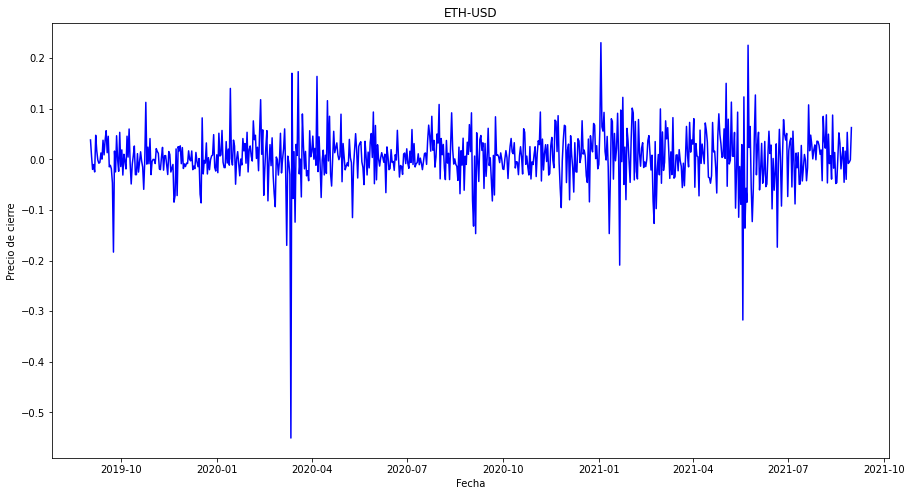

In [ ]:
plt.figure(figsize=(15,8))
plt.plot(df['Log Returns'], color='blue')
plt.title('ETH-USD')
plt.xlabel('Fecha')
plt.ylabel(' Precio de cierre ')
plt.show()

In [ ]:
#Volatilidad
vol_d=  np.std(df['Log Returns'])
vol_d
#volatilidad anualizada
vol_a= vol_d*np.sqrt(252)
vol_a

0.8465930452865625